In [1]:
from utils import *

import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split


import keras
from keras.callbacks import ReduceLROnPlateau
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, BatchNormalization
#from keras.utils import np_utils
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint
import tensorflow as tf

import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# LSTM Classifier
import keras
from keras.models import Sequential
from keras.layers import *
from keras.regularizers import l2, l1, l1_l2

from tensorflow.keras import layers,regularizers,models
from tensorflow import keras


2024-10-22 20:27:18.664055: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-22 20:27:18.747385: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-22 20:27:18.842615: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-22 20:27:18.935112: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-22 20:27:18.964160: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-22 20:27:19.112881: I tensorflow/core/platform/cpu_feature_gu

In [2]:
RAV = 'Ravdess/'
dir_list = os.listdir(RAV)

emotion = []
gender = []
path = []
feature = []
for i in dir_list:
    fname = os.listdir(RAV + i)
    for f in fname:
        part = f.split('.')[0].split('-')
        emotion.append(int(part[2]))
        temp = int(part[6])
        if temp%2 == 0:
            temp = "female"
        else:
            temp = "male"
        gender.append(temp)
        path.append(RAV + i + '/' + f)
        
RAV_df = pd.DataFrame(emotion)
RAV_df = RAV_df.replace({1:'neutral', 2:'neutral', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 8:'surprise'})
RAV_df = pd.concat([pd.DataFrame(gender),RAV_df],axis=1)
RAV_df.columns = ['gender','emotion']
RAV_df['labels'] =RAV_df.gender + '_' + RAV_df.emotion
RAV_df['source'] = 'RAVDESS'
RAV_df = pd.concat([RAV_df,pd.DataFrame(path, columns = ['path'])],axis=1)
RAV_df = RAV_df.drop(['gender'], axis=1)
RAV_df.labels.value_counts()

labels
male_neutral       144
female_neutral     144
male_happy          96
male_sad            96
male_angry          96
male_disgust        96
male_fear           96
male_surprise       96
female_happy        96
female_sad          96
female_surprise     96
female_angry        96
female_disgust      96
female_fear         96
Name: count, dtype: int64

X, Y = [], []
for path, emotion in zip(RAV_df.path, RAV_df.emotion):
    feature = get_features(path)
    for ele in feature:
        X.append(ele)
        # appending emotion 3 times as we have made 3 augmentation techniques on each audio file.
        Y.append(emotion)

Features = pd.DataFrame(X)
Features['labels'] = Y
Features.to_csv('features1.csv', index=False)

In [3]:
Features = pd.read_csv('features1.csv')
Features.head()

,0,1,2,3,4,5,6,7,8,9,...,153,154,155,156,157,158,159,160,161,labels
0,0.223520,0.624093,0.615632,0.633310,0.630466,0.684019,0.662871,0.613144,0.584559,0.601855,...,0.000298,0.000433,0.000207,0.000172,0.000155,0.000167,0.000206,0.000109,8.725961e-06,happy
1,0.308101,0.697112,0.722029,0.734569,0.728162,0.762911,0.712632,0.632978,0.629908,0.657404,...,0.002186,0.002457,0.002049,0.002108,0.002171,0.002265,0.002120,0.001998,1.942927e-03,happy
2,0.122461,0.677245,0.560857,0.584405,0.598932,0.627010,0.656732,0.638749,0.583185,0.568163,...,0.000030,0.000047,0.000086,0.000101,0.000034,0.000033,0.000027,0.000026,2.569428e-06,happy
3,0.285606,0.756783,0.735766,0.773450,0.754597,0.694107,0.679730,0.657213,0.723302,0.760122,...,0.000008,0.000014,0.000015,0.000016,0.000015,0.000020,0.000017,0.000008,3.868911e-07,neutral
4,0.315657,0.785199,0.777367,0.805918,0.800451,0.776352,0.717911,0.654979,0.707236,0.752007,...,0.000015,0.000021,0.000022,0.000023,0.000023,0.000028,0.000025,0.000015,7.903967e-06,neutral


In [4]:
X = Features.iloc[: ,:-1].values
Y = Features['labels'].values
X.shape,Y.shape

((4320, 162), (4320,))

In [5]:
from sklearn.utils import shuffle
temp = shuffle(Features)
# temp[:10]


df = np.random.rand(len(temp)) < 0.8
train = temp[df]
test = temp[~df]


trainfeatures = train.iloc[:, :-1]
trainlabel = train.iloc[:, -1:]
testfeatures = test.iloc[:, :-1]
testlabel = test.iloc[:, -1:]


#from keras.utils import np_utils
from sklearn.preprocessing import LabelEncoder

X_train = np.array(trainfeatures)
y_train = np.array(trainlabel)
X_test = np.array(testfeatures)
y_test = np.array(testlabel)

lb = LabelEncoder()

y_train = to_categorical(lb.fit_transform(y_train))
y_test = to_categorical(lb.fit_transform(y_test))


In [6]:
X_train.shape

(3527, 162)

In [7]:
X_test.shape

(793, 162)

In [8]:
x_train = np.expand_dims(X_train, axis=2)
x_test = np.expand_dims(X_test, axis=2)

In [9]:
x_train.shape

(3527, 162, 1)

In [10]:
x_test.shape

(793, 162, 1)

In [11]:
y_train.shape

(3527, 7)

In [12]:
y_test.shape

(793, 7)

In [13]:
model = Sequential()
model.add(BatchNormalization(axis=-1, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(256, return_sequences=True,kernel_regularizer=regularizers.l2(1e-5)))
model.add(LSTM(256, return_sequences=True,kernel_regularizer=regularizers.l2(1e-5)))
model.add(LSTM(128, return_sequences=True,kernel_regularizer=regularizers.l2(1e-5)))
model.add(BatchNormalization())
model.add(Flatten())

# model.add(Dense(32))
# model.add(Dropout(0.4))
# model.add(Activation('relu'))

model.add(Dense(7))
model.add(Activation('softmax'))
model.compile(loss='categorical_crossentropy', optimizer='RMSProp', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 162, 1)         │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 162, 256)       │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 162, 256)       │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 162, 128)       │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 162, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │       145,159 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 7)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,132,299 (4.32 MB)

 Trainable params: 1,132,041 (4.32 MB)

 Non-trainable params: 258 (1.01 KB)

In [14]:
history=model.fit(X_train, y_train, batch_size=256, epochs=1000, validation_data=(X_test, y_test), shuffle=True)

Epoch 1/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.1623 - loss: 4.0831 - val_accuracy: 0.1929 - val_loss: 1.9338
Epoch 2/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.2677 - loss: 1.8420 - val_accuracy: 0.2055 - val_loss: 1.9332
Epoch 3/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.2717 - loss: 1.8027 - val_accuracy: 0.2396 - val_loss: 1.9218
Epoch 4/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.2672 - loss: 1.8161 - val_accuracy: 0.2598 - val_loss: 1.9201
Epoch 5/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.2915 - loss: 1.7757 - val_accuracy: 0.2522 - val_loss: 1.8963
Epoch 6/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.2656 - loss: 1.8565 - val_accuracy: 0.2055 - val_loss: 1.9238
Epoch 7/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.3295 - loss: 1.7018 - val_accuracy: 0.2484 - val_loss: 1.9210
Epoch 8/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.3107 - loss: 1.7271 - val_accuracy: 0.

25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 264ms/step - accuracy: 0.7918 - loss: 1.7048
Accuracy of our model on test data :  80.83228468894958 %


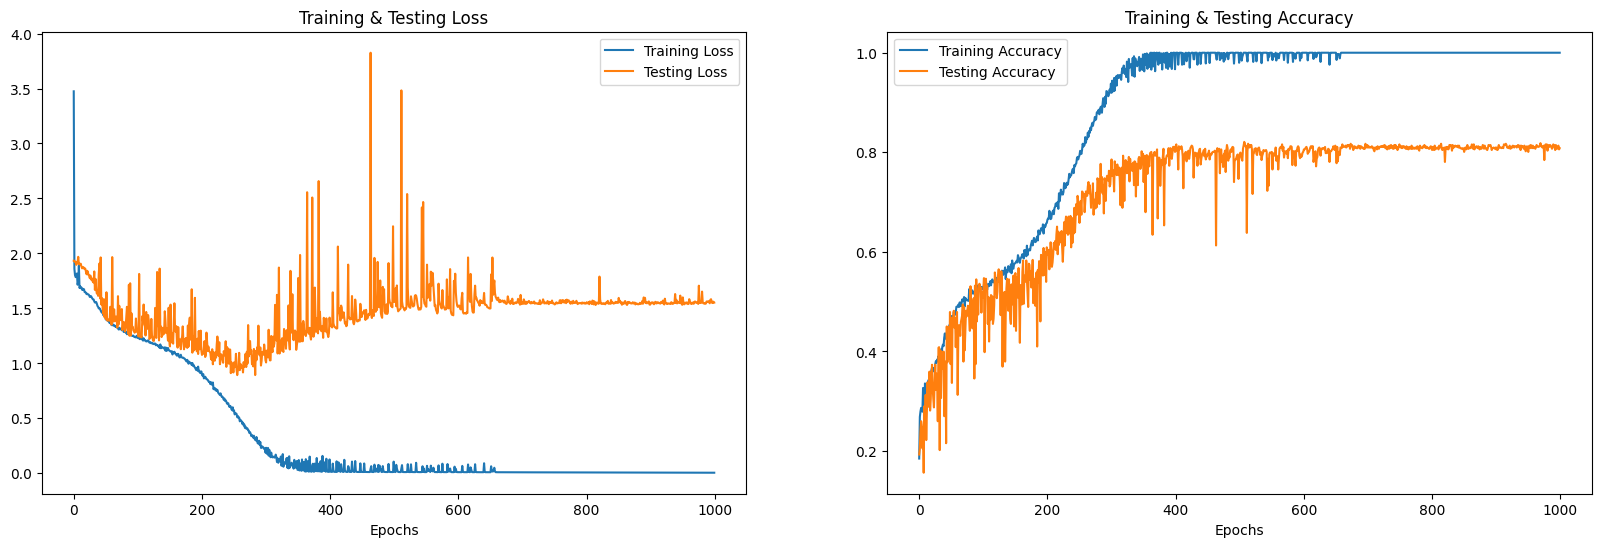

In [16]:
print("Accuracy of our model on test data : " , model.evaluate(X_test,y_test)[1]*100 , "%")

epochs = [i for i in range(1000)]
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
test_acc = history.history['val_accuracy']
test_loss = history.history['val_loss']

fig.set_size_inches(20,6)
ax[0].plot(epochs , train_loss , label = 'Training Loss')
ax[0].plot(epochs , test_loss , label = 'Testing Loss')
ax[0].set_title('Training & Testing Loss')
ax[0].legend()
ax[0].set_xlabel("Epochs")

ax[1].plot(epochs , train_acc , label = 'Training Accuracy')
ax[1].plot(epochs , test_acc , label = 'Testing Accuracy')
ax[1].set_title('Training & Testing Accuracy')
ax[1].legend()
ax[1].set_xlabel("Epochs")
plt.show()

In [17]:
model.save('LSTM_model.h5')